# Mission 1 — 신고자 성별 분류 (Wav2Vec2 파인튜닝 접근)

담당: 김하은

음성으로부터 신고자의 성별(남/여)을 분류한다. 신고자(`speaker == 1`) 발화 구간만
잘라내 이어붙인 뒤 3초 단위로 나누어 조각 단위 이진 분류기를 학습하고, 한 통화의
조각별 확률을 평균(soft voting)해 통화의 최종 성별을 결정한다.

이 노트북은 학습 300통화 / 검증(공식 Validation 폴더) 150통화 규모의 소규모
샘플로 접근 방식을 빠르게 검증해본 탐색용 노트북이다. 같은 팀의 김승윤 님이
전체 데이터(학습 29,200통화 / 검증 3,640통화)로 CNN(ResNet50)과 Wav2Vec2를 이미
비교해두었고, 이 노트북에서 소규모로 얻은 결론(soft voting 적용 시 정확도 상승)이
그 결과와 같은 방향임을 독립적으로 확인했다.

## 0. 환경 설정

In [ ]:
!nvidia-smi

Mon Sep  7 07:39:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q librosa soundfile transformers scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 아래 경로는 본인 Drive 구조에 맞게 수정하세요.
# 예: /content/drive/MyDrive/DCC_data/구급/  안에 wav, json이 같이 있는 구조
DATA_ROOT = "/content/drive/MyDrive/DCC_data"
print(DATA_ROOT)

Mounted at /content/drive
/content/drive/MyDrive/DCC_data


## 1. 데이터 경로 및 파일 확인

Google Drive에 바로가기로 연결해둔 대회 공식 데이터 폴더에서 wav/json 경로를 확인하고, 두 파일 개수가 일치하는지 검증한다.

In [ ]:
import os
target = '/content/drive/MyDrive/대학부 데이터'
print("존재함?", os.path.exists(target))
if os.path.exists(target):
    print(os.listdir(target))

존재함? True
['Training', 'Validation']


In [ ]:
train_path = os.path.join(target, "Training")
print(os.listdir(train_path))

['1.원천데이터', '2.라벨링데이터']


In [ ]:
audio_root = os.path.join(train_path, "1.원천데이터")
label_root = os.path.join(train_path, "2.라벨링데이터")

print("원천데이터 폴더들:", os.listdir(audio_root))
print("라벨링데이터 폴더들:", os.listdir(label_root))

원천데이터 폴더들: ['TS_서울_구급']
라벨링데이터 폴더들: ['TL_서울_구급']


In [ ]:
WAV_DIR = os.path.join(audio_root, "TS_서울_구급")
JSON_DIR = os.path.join(label_root, "TL_서울_구급")

wav_files = sorted([f for f in os.listdir(WAV_DIR) if f.endswith(".wav")])
json_files = sorted([f for f in os.listdir(JSON_DIR) if f.endswith(".json")])

print("wav 개수:", len(wav_files))
print("json 개수:", len(json_files))
print("샘플 wav:", wav_files[:3])
print("샘플 json:", json_files[:3])

# 파일명(확장자 제외)이 실제로 1:1로 매칭되는지 확인
wav_stems = set(f[:-4] for f in wav_files)
json_stems = set(f[:-5] for f in json_files)
print("매칭 안 되는 wav:", len(wav_stems - json_stems))
print("매칭 안 되는 json:", len(json_stems - wav_stems))

wav 개수: 29200
json 개수: 29200
샘플 wav: ['651e464d69a4f266f062680b_20220101.wav', '651e464d69a4f266f0626810_20220101.wav', '651e464d69a4f266f062681a_20220101.wav']
샘플 json: ['651e464d69a4f266f062680b_20220101.json', '651e464d69a4f266f0626810_20220101.json', '651e464d69a4f266f062681a_20220101.json']
매칭 안 되는 wav: 0
매칭 안 되는 json: 0


## 2. 라벨(JSON) 구조 확인

Mission 1에서 입력으로 쓸 수 있는 필드는 `startAt`, `endAt`, `speaker`뿐이고 정답(타깃)은 `gender`다. 실제 JSON 구조를 한 번 확인한다.

In [ ]:
import json

sample_json_path = os.path.join(JSON_DIR, json_files[0])
with open(sample_json_path, "r", encoding="utf-8") as f:
    label = json.load(f)

print(json.dumps(label, indent=2, ensure_ascii=False))

{
  "_id": "651e464d69a4f266f062680b",
  "audioPath": "20230925/Seoul/2022/20220101/converted_[20220101]-[WO1139276649].wav",
  "recordId": "fa5bdda9610ee0353bc9",
  "status": 12,
  "startAt": 0,
  "endAt": 47640,
  "utterances": [
    {
      "id": "6ed76bbd",
      "startAt": 348,
      "endAt": 1765,
      "text": "예 119입니다.",
      "speaker": 0
    },
    {
      "id": "1ea3a8e1",
      "startAt": 2032,
      "endAt": 6562,
      "text": "예, 어제 코로나 백신 주사를 맞고요. 너무 아파서 이 그",
      "speaker": 1
    },
    {
      "id": "dac55777",
      "startAt": 4858,
      "endAt": 7427,
      "text": "아 예 네 누가 그러신 거예요?",
      "speaker": 0
    },
    {
      "id": "f91a1d75",
      "startAt": 7727,
      "endAt": 9067,
      "text": "예예, 집사람이 좀.",
      "speaker": 1
    },
    {
      "id": "c19ac26b",
      "startAt": 9127,
      "endAt": 12514,
      "text": "아, 아내분께서요. 지금 백신 맞고 지금 마 아, 많이 아파하시는 거예요?",
      "speaker": 0
    },
    {
      "id": "0e4d7177",
      "startAt": 12244,
      "endAt":

## 3. 전처리 — 신고자 음성 추출 & 윈도우 분할

1. `load_caller_audio`: JSON의 `startAt`/`endAt`으로 신고자(`speaker==1`) 구간만 잘라 이어붙인다.
2. `make_windows`: 이어붙인 음성을 3초 단위로 잘라 모델 입력 조각을 만든다 (마지막 조각은 0으로 패딩).

In [ ]:
import librosa
import numpy as np

def load_caller_audio(json_path, wav_path, target_speaker=1, sr=16000):
    with open(json_path, "r", encoding="utf-8") as f:
        label = json.load(f)

    gender = label["gender"]  # 정답 라벨 (M/F)

    # 신고자(speaker=1) 발화 구간만 골라내기
    caller_segments = [
        (u["startAt"], u["endAt"])
        for u in label["utterances"]
        if u["speaker"] == target_speaker
    ]

    y, _ = librosa.load(wav_path, sr=sr)  # 전체 오디오 로드

    clips = []
    for start_ms, end_ms in caller_segments:
        start_sample = int(start_ms / 1000 * sr)
        end_sample = int(end_ms / 1000 * sr)
        clips.append(y[start_sample:end_sample])

    if len(clips) == 0:
        return None, gender  # 이 통화에 신고자 발화가 없는 예외 케이스

    caller_audio = np.concatenate(clips)  # 신고자 발화만 이어붙이기
    return caller_audio, gender

In [ ]:
import os

sample_wav = os.path.join(WAV_DIR, wav_files[0])
sample_json = os.path.join(JSON_DIR, json_files[0])

caller_audio, gender = load_caller_audio(sample_json, sample_wav)

print("성별 라벨:", gender)
print("신고자 음성만 자른 길이(초):", len(caller_audio) / 16000)

성별 라벨: M
신고자 음성만 자른 길이(초): 28.159


In [ ]:
for i in range(10):
    w = os.path.join(WAV_DIR, wav_files[i])
    j = os.path.join(JSON_DIR, json_files[i])
    audio, gender = load_caller_audio(j, w)
    length = len(audio) / 16000 if audio is not None else 0
    print(f"{i}: gender={gender}, 길이={length:.2f}초")

0: gender=M, 길이=28.16초
1: gender=F, 길이=25.33초
2: gender=F, 길이=36.26초
3: gender=F, 길이=18.02초
4: gender=M, 길이=33.08초
5: gender=F, 길이=29.95초
6: gender=F, 길이=47.29초
7: gender=F, 길이=30.36초
8: gender=M, 길이=15.45초
9: gender=F, 길이=21.59초


In [ ]:
def make_windows(audio, sr=16000, window_sec=3, stride_sec=3):
    window_samples = int(window_sec * sr)
    stride_samples = int(stride_sec * sr)

    windows = []
    start = 0
    while start < len(audio):
        chunk = audio[start : start + window_samples]

        # 마지막 조각이 3초보다 짧으면 0(묵음)으로 채움
        if len(chunk) < window_samples:
            pad_width = window_samples - len(chunk)
            chunk = np.pad(chunk, (0, pad_width))

        windows.append(chunk)
        start += stride_samples

    return windows

In [ ]:
windows = make_windows(caller_audio)
print("조각 개수:", len(windows))
print("조각 하나 길이(샘플 수):", len(windows[0]))
print("조각 하나 길이(초):", len(windows[0]) / 16000)

조각 개수: 10
조각 하나 길이(샘플 수): 48000
조각 하나 길이(초): 3.0


## 4. EDA — 발화 길이 분포로 윈도우 길이 판단

신고자 개별 발화 하나하나는 매우 짧은 경우가 많다("네"/"아니오" 등). 발화를 낱개로 잘라 쓰면 패딩이 커지므로, 이어붙인 뒤 자르는 방식과 윈도우 길이별 트레이드오프를 데이터로 직접 확인한다.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

N_ANALYZE = 1000   # 더 늘리고 싶으면 이 숫자만 바꾸면 돼요

utt_durations, rows = [], []

for i in tqdm(range(N_ANALYZE)):
    with open(os.path.join(JSON_DIR, json_files[i]), "r", encoding="utf-8") as f:
        label = json.load(f)

    caller = [u for u in label["utterances"] if u["speaker"] == 1]
    durs = [(u["endAt"] - u["startAt"]) / 1000 for u in caller]
    if len(durs) == 0:
        continue

    utt_durations.extend(durs)
    rows.append({
        "file": json_files[i],
        "gender": label["gender"],
        "n_utt": len(durs),
        "total_sec": float(np.sum(durs)),
        "mean_utt_sec": float(np.mean(durs)),
    })

df = pd.DataFrame(rows)
utt = np.array(utt_durations)
tot = df["total_sec"].values

print("분석한 통화 수:", len(df), "/ 신고자 발화 총 개수:", len(utt))

  0%|          | 0/1000 [00:00<?, ?it/s]

분석한 통화 수: 1000 / 신고자 발화 총 개수: 15562


In [ ]:
print("=== 개별 발화 길이(초) ===")
for p in [10, 25, 50, 75, 90]:
    print(f"  {p}분위: {np.percentile(utt, p):.2f}초")
for t in [0.5, 1, 2, 3, 5]:
    print(f"  {t}초 미만 비율: {(utt < t).mean()*100:.1f}%")

print("\n=== 통화당 신고자 발화 총합(초) ===")
print(f"  평균 {tot.mean():.1f} / 중앙값 {np.median(tot):.1f} / 최소 {tot.min():.1f} / 최대 {tot.max():.1f}")

print("\n=== 성별별 ===")
print(df.groupby("gender")["total_sec"].agg(["count", "mean", "median"]))

=== 개별 발화 길이(초) ===
  10분위: 0.55초
  25분위: 0.84초
  50분위: 1.56초
  75분위: 2.92초
  90분위: 4.75초
  0.5초 미만 비율: 7.0%
  1초 미만 비율: 31.8%
  2초 미만 비율: 60.2%
  3초 미만 비율: 75.9%
  5초 미만 비율: 91.1%

=== 통화당 신고자 발화 총합(초) ===
  평균 33.9 / 중앙값 31.1 / 최소 4.3 / 최대 97.8

=== 성별별 ===
        count       mean  median
gender                          
F         489  34.840493  32.008
M         511  33.058012  30.195


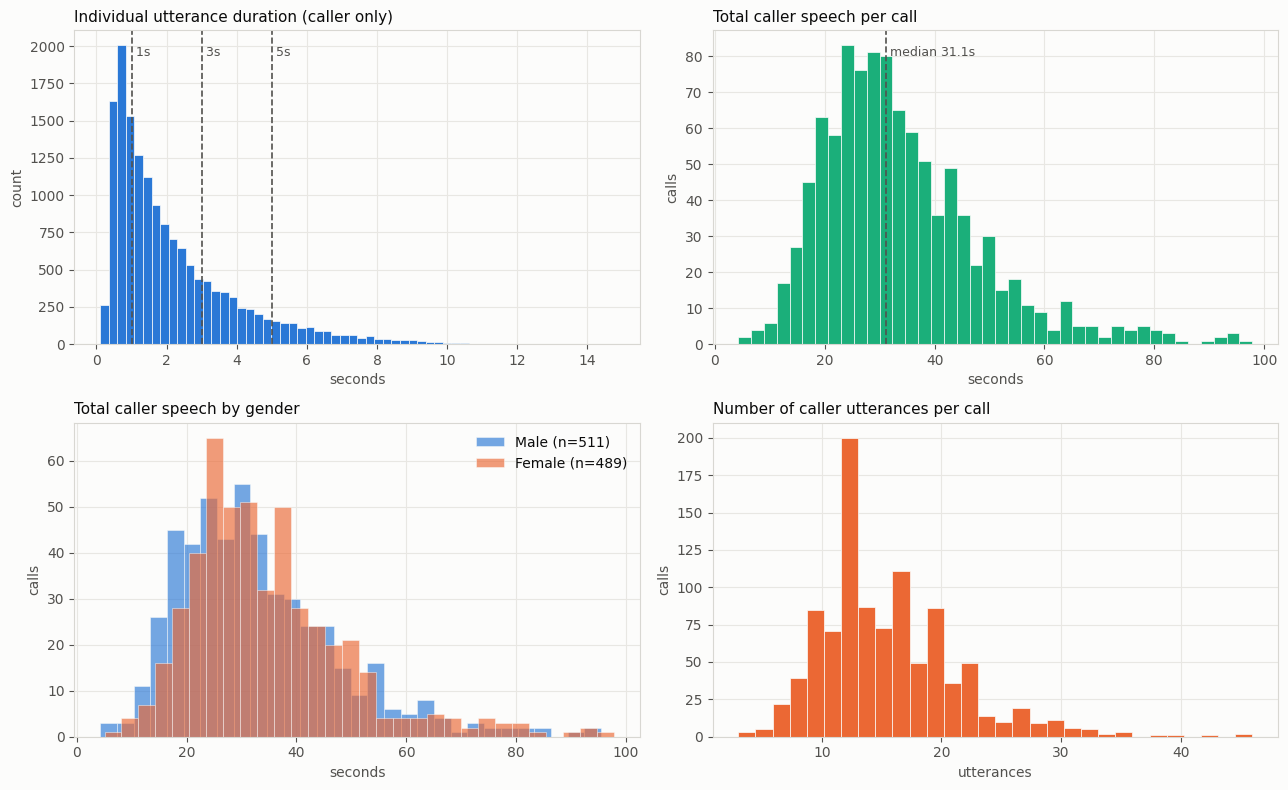

In [ ]:
import matplotlib.pyplot as plt

C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2 = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#d8d7d2", "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10,
})

fig, ax = plt.subplots(2, 2, figsize=(13, 8))

a = ax[0, 0]
a.hist(utt[utt <= 15], bins=60, color=C1, edgecolor="#fcfcfb", linewidth=0.5)
for x, lab in [(1, "1s"), (3, "3s"), (5, "5s")]:
    a.axvline(x, color=INK2, linestyle="--", linewidth=1.2)
    a.text(x, a.get_ylim()[1] * 0.95, f" {lab}", color=INK2, fontsize=9, va="top")
a.set_title("Individual utterance duration (caller only)", color=INK, fontsize=11, loc="left")
a.set_xlabel("seconds"); a.set_ylabel("count")

a = ax[0, 1]
a.hist(tot, bins=40, color=C3, edgecolor="#fcfcfb", linewidth=0.5)
a.axvline(np.median(tot), color=INK2, linestyle="--", linewidth=1.2)
a.text(np.median(tot), a.get_ylim()[1] * 0.95, f" median {np.median(tot):.1f}s",
       color=INK2, fontsize=9, va="top")
a.set_title("Total caller speech per call", color=INK, fontsize=11, loc="left")
a.set_xlabel("seconds"); a.set_ylabel("calls")

a = ax[1, 0]
for g, c, lab in [("M", C1, "Male"), ("F", C2, "Female")]:
    v = df.loc[df.gender == g, "total_sec"].values
    a.hist(v, bins=30, alpha=0.65, color=c, label=f"{lab} (n={len(v)})",
           edgecolor="#fcfcfb", linewidth=0.5)
a.legend(frameon=False)
a.set_title("Total caller speech by gender", color=INK, fontsize=11, loc="left")
a.set_xlabel("seconds"); a.set_ylabel("calls")

a = ax[1, 1]
a.hist(df["n_utt"].values, bins=30, color=C2, edgecolor="#fcfcfb", linewidth=0.5)
a.set_title("Number of caller utterances per call", color=INK, fontsize=11, loc="left")
a.set_xlabel("utterances"); a.set_ylabel("calls")

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "fig1_data_distribution.png"), dpi=130)
plt.show()

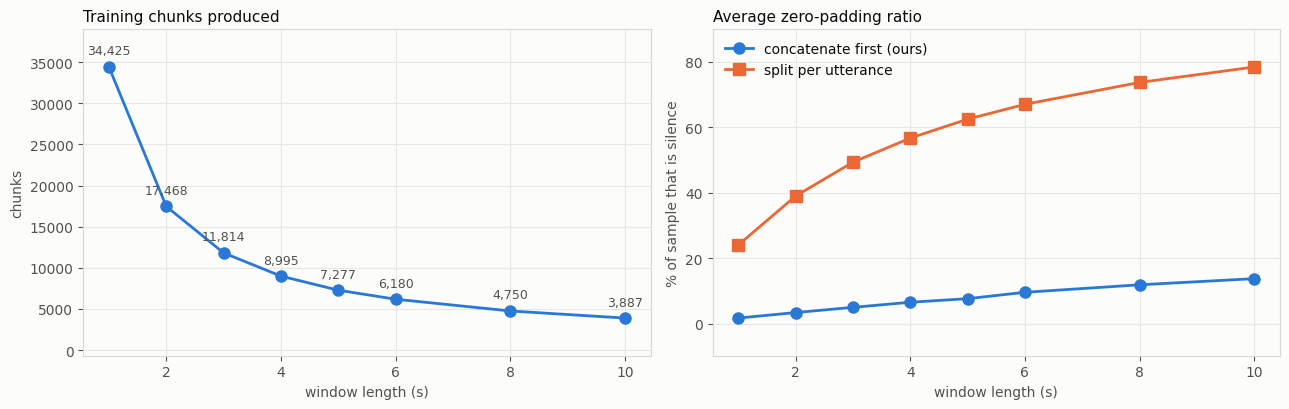

   window_sec  chunks  pad_concat_%  pad_perutt_%
0           1   34425           1.7          24.0
1           2   17468           3.4          38.9
2           3   11814           5.0          49.3
3           4    8995           6.5          56.6
4           5    7277           7.6          62.4
5           6    6180           9.6          66.9
6           8    4750          11.9          73.6
7          10    3887          13.7          78.3


In [ ]:
Ws = [1, 2, 3, 4, 5, 6, 8, 10]
n_chunks, pad_concat, pad_perutt = [], [], []
for W in Ws:
    n = np.ceil(tot / W)
    n_chunks.append(int(n.sum()))
    pad_concat.append(float(((n * W - tot) / (n * W)).mean() * 100))
    nu = np.ceil(utt / W)
    pad_perutt.append(float(((nu * W - utt) / (nu * W)).mean() * 100))

fig2, ax2 = plt.subplots(1, 2, figsize=(13, 4.2))

a = ax2[0]
a.plot(Ws, n_chunks, marker="o", color=C1, linewidth=2, markersize=8)
for x, yv in zip(Ws, n_chunks):
    a.annotate(f"{yv:,}", (x, yv), textcoords="offset points", xytext=(0, 9),
               ha="center", fontsize=9, color=INK2)
a.margins(y=0.15)
a.set_title("Training chunks produced", color=INK, fontsize=11, loc="left")
a.set_xlabel("window length (s)"); a.set_ylabel("chunks")

a = ax2[1]
a.plot(Ws, pad_concat, marker="o", color=C1, linewidth=2, markersize=8,
       label="concatenate first (ours)")
a.plot(Ws, pad_perutt, marker="s", color=C2, linewidth=2, markersize=8,
       label="split per utterance")
a.legend(frameon=False); a.margins(y=0.15)
a.set_title("Average zero-padding ratio", color=INK, fontsize=11, loc="left")
a.set_xlabel("window length (s)"); a.set_ylabel("% of sample that is silence")

fig2.tight_layout()
fig2.savefig(os.path.join(SAVE_DIR, "fig2_window_tradeoff.png"), dpi=130)
plt.show()

print(pd.DataFrame({"window_sec": Ws, "chunks": n_chunks,
                    "pad_concat_%": np.round(pad_concat, 1),
                    "pad_perutt_%": np.round(pad_perutt, 1)}))

**결론**: 개별 발화 중앙값은 1.56초로 매우 짧아, 발화 단위로 자르면 윈도우가 길어질수록 패딩이 급격히 커진다(10초 기준 78.3%). 신고자 발화를 전부 이어붙인 뒤 자르는 방식은 같은 10초 기준으로도 패딩이 13.7%에 그친다. 윈도우 3초는 청크 수(11,814개)와 패딩 비율(5.0%)의 균형이 좋아 이 값을 최종 윈도우 길이로 선택했다.

## 5. 학습 데이터셋 구성 (Training, 300통화 샘플)

In [ ]:
from tqdm.auto import tqdm

N_FILES = 300              # 우선 300개만으로 검증
MAX_WINDOWS_PER_FILE = 5   # 통화 하나당 최대 5조각 (긴 통화가 데이터 독점하는 것 방지)

X, y = [], []

for i in tqdm(range(N_FILES)):
    w = os.path.join(WAV_DIR, wav_files[i])
    j = os.path.join(JSON_DIR, json_files[i])

    audio, gender = load_caller_audio(j, w)
    if audio is None:
        continue

    windows = make_windows(audio)[:MAX_WINDOWS_PER_FILE]

    for chunk in windows:
        X.append(chunk.astype(np.float32))
        y.append(0 if gender == "M" else 1)   # M=0, F=1

X = np.stack(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("M 조각 수:", (y == 0).sum(), "/ F 조각 수:", (y == 1).sum())

  0%|          | 0/300 [00:00<?, ?it/s]

X shape: (1487, 48000)
y shape: (1487,)
M 조각 수: 734 / F 조각 수: 753


In [ ]:
SAVE_DIR = '/content/drive/MyDrive/dcc_mission1'
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(os.path.join(SAVE_DIR, 'X_train_300.npy'), X)
np.save(os.path.join(SAVE_DIR, 'y_train_300.npy'), y)
print("저장 완료:", os.listdir(SAVE_DIR))

저장 완료: ['X_train_300.npy', 'y_train_300.npy', 'X_val_150.npy', 'y_val_150.npy', 'groups_val_150.npy', 'wav2vec2_gender_v1.pt', 'fig1_data_distribution.png', 'fig2_window_tradeoff.png']


## 6. 검증 데이터셋 구성 (공식 Validation 폴더, 150통화 샘플)

학습에 쓴 Training 폴더가 아니라 대회가 별도로 제공하는 Validation 폴더에서만 검증 데이터를 뽑는다.

In [ ]:
val_root = os.path.join(target, "Validation")
print(os.listdir(val_root))
print(os.listdir(os.path.join(val_root, "1.원천데이터")))
print(os.listdir(os.path.join(val_root, "2.라벨링데이터")))

['2.라벨링데이터', '1.원천데이터']
['VS_서울_구급']
['VL_서울_구급']


In [ ]:
VAL_WAV_DIR = os.path.join(val_root, "1.원천데이터", "VS_서울_구급")
VAL_JSON_DIR = os.path.join(val_root, "2.라벨링데이터", "VL_서울_구급")

val_wav_files = sorted([f for f in os.listdir(VAL_WAV_DIR) if f.endswith(".wav")])
val_json_files = sorted([f for f in os.listdir(VAL_JSON_DIR) if f.endswith(".json")])

print("검증 wav 개수:", len(val_wav_files), "/ json 개수:", len(val_json_files))

검증 wav 개수: 3640 / json 개수: 3640


In [ ]:
N_VAL_FILES = 150

X_val, y_val, groups_val = [], [], []

for i in tqdm(range(N_VAL_FILES)):
    w = os.path.join(VAL_WAV_DIR, val_wav_files[i])
    j = os.path.join(VAL_JSON_DIR, val_json_files[i])

    audio, gender = load_caller_audio(j, w)
    if audio is None:
        continue

    windows = make_windows(audio)[:MAX_WINDOWS_PER_FILE]

    for chunk in windows:
        X_val.append(chunk.astype(np.float32))
        y_val.append(0 if gender == "M" else 1)
        groups_val.append(i)   # 이 조각이 몇 번째 통화에서 나왔는지 기록

X_val = np.stack(X_val)
y_val = np.array(y_val)
groups_val = np.array(groups_val)

print("X_val shape:", X_val.shape)
print("M 조각 수:", (y_val == 0).sum(), "/ F 조각 수:", (y_val == 1).sum())

  0%|          | 0/150 [00:00<?, ?it/s]

X_val shape: (747, 48000)
M 조각 수: 357 / F 조각 수: 390


In [ ]:
np.save(os.path.join(SAVE_DIR, 'X_val_150.npy'), X_val)
np.save(os.path.join(SAVE_DIR, 'y_val_150.npy'), y_val)
np.save(os.path.join(SAVE_DIR, 'groups_val_150.npy'), groups_val)
print("저장 완료:", os.listdir(SAVE_DIR))

저장 완료: ['X_train_300.npy', 'y_train_300.npy', 'X_val_150.npy', 'y_val_150.npy', 'groups_val_150.npy', 'wav2vec2_gender_v1.pt', 'fig1_data_distribution.png', 'fig2_window_tradeoff.png']


## 7. 모델 — Wav2Vec2-base 파인튜닝

`facebook/wav2vec2-base`에 `freeze_feature_encoder()`로 특징 추출기를 고정하고, 분류 헤드만 학습한다 (lr=3e-5, 3 epoch).

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

MODEL_NAME = "facebook/wav2vec2-base"
device = "cuda" if torch.cuda.is_available() else "cpu"

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
model = AutoModelForAudioClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
model.freeze_feature_encoder()   # 앞단 CNN은 고정 (학습 빠르고 안정적)

print("모델 로드 완료 / device:", device)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  380MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


모델 로드 완료 / device: cuda


In [ ]:
class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        inputs = feature_extractor(self.X[idx], sampling_rate=16000, return_tensors="pt")
        return {
            "input_values": inputs["input_values"].squeeze(0),
            "labels": torch.tensor(self.y[idx], dtype=torch.long),
        }

train_loader = DataLoader(AudioDataset(X, y), batch_size=8, shuffle=True)
val_loader = DataLoader(AudioDataset(X_val, y_val), batch_size=8, shuffle=False)

print("배치 수 - 학습:", len(train_loader), "/ 검증:", len(val_loader))

배치 수 - 학습: 186 / 검증: 94


In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=3e-5)
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} 학습"):
        input_values = batch["input_values"].to(device)
        labels = batch["labels"].to(device)

        loss = model(input_values=input_values, labels=labels).loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1} 검증"):
            input_values = batch["input_values"].to(device)
            labels = batch["labels"].to(device)

            preds = model(input_values=input_values).logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    print(f"[Epoch {epoch+1}] loss: {total_loss/len(train_loader):.4f} / 검증 정확도: {correct/total:.4f}")

Epoch 1 학습:   0%|          | 0/186 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  380MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1 검증:   0%|          | 0/94 [00:00<?, ?it/s]

[Epoch 1] loss: 0.3704 / 검증 정확도: 0.8527


...

Epoch 2 검증:   0%|          | 0/94 [00:00<?, ?it/s]

[Epoch 2] loss: 0.2161 / 검증 정확도: 0.9076


Epoch 3 학습:   0%|          | 0/186 [00:00<?, ?it/s]

Epoch 3 검증:   0%|          | 0/94 [00:00<?, ?it/s]

[Epoch 3] loss: 0.1889 / 검증 정확도: 0.9210


In [ ]:
torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'wav2vec2_gender_v1.pt'))
print("모델 저장 완료:", os.listdir(SAVE_DIR))

모델 저장 완료: ['X_train_300.npy', 'y_train_300.npy', 'X_val_150.npy', 'y_val_150.npy', 'groups_val_150.npy', 'wav2vec2_gender_v1.pt', 'fig1_data_distribution.png', 'fig2_window_tradeoff.png']


## 8. 검증 — 조각 단위 정확도 & 통화 단위 soft voting

통화별로 조각들의 예측 확률을 평균(soft voting)해 0.5 기준으로 최종 성별을 판정한다. (다수결(hard voting) 대비 확인된 개선: 통화 단위 정확도 0.92 → 0.9667)

In [ ]:
import torch.nn.functional as F

model.eval()
all_probs = []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="예측 수집"):
        input_values = batch["input_values"].to(device)
        logits = model(input_values=input_values).logits
        probs = F.softmax(logits, dim=-1)[:, 1]   # 클래스 1일 확률
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs).numpy()
all_preds = (all_probs > 0.5).astype(int)   # 조각 단위 정확도 계산용

# 통화 단위로 확률 평균(soft voting)
correct_calls = total_calls = 0
for g in np.unique(groups_val):
    mask = groups_val == g
    avg_prob = all_probs[mask].mean()       # 조각들의 확률을 평균
    vote = int(avg_prob > 0.5)
    true_label = y_val[mask][0]
    correct_calls += int(vote == true_label)
    total_calls += 1

print(f"조각 단위 정확도: {(all_preds == y_val).mean():.4f}")
print(f"통화 단위 정확도(soft voting): {correct_calls/total_calls:.4f}  ({correct_calls}/{total_calls})")

예측 수집:   0%|          | 0/94 [00:00<?, ?it/s]

조각 단위 정확도: 0.9210
통화 단위 정확도(soft voting): 0.9667  (145/150)


## 9. 결론

- 신고자 발화만 추출 → 이어붙이기 → 3초 윈도우 분할 → Wav2Vec2 파인튜닝 → 통화 단위
  soft voting 집계 파이프라인으로, 학습 300통화 / 검증(공식 Validation) 150통화
  규모에서 **조각 단위 정확도 92.10%, 통화 단위 정확도 96.67%(145/150)**를 얻었다.
- 다수결(hard voting) 대비 soft voting으로 바꾼 것만으로 통화 단위 정확도가
  92.00% → 96.67%로 올랐다. 확률 정보를 버리지 않는 집계 방식이 소규모 샘플에서도
  뚜렷한 개선을 만든다는 걸 확인했다.
- 이 노트북은 학습·검증 모두 소규모 샘플(300/150)이라 절대적인 수치보다는
  **접근 방식(신고자 구간 이어붙이기 + soft voting)이 유효하다는 방향성 확인**에
  의미가 있다. 같은 팀 김승윤 님이 전체 데이터(29,200/3,640)로 CNN(ResNet50)과
  Wav2Vec2를 비교한 결과(각각 97.91%, 98.35%)가 이 노트북의 결론과 같은 방향이라,
  최종 제출은 전체 데이터 기준으로 검증된 그쪽 파이프라인을 기반으로 진행하기로
  팀 내에서 정리했다.